<a href="https://colab.research.google.com/github/sofiarubini02/bank-marketing-machine-learning/blob/main/bank_marketing_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **PROGETTO: ANALISI DEL DATASET BANK MARKETING**

# **INTRODUZIONE DEL DATASET**

Per questo progetto abbiamo utilizzato il dataset reale "Bank Marketing", reso disponibile dall'[UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/datasets/bank+marketing).

Il dataset contiene informazioni raccolte nell’ambito di campagne di marketing diretto condotte da una banca portoghese, svolte tramite chiamate telefoniche a potenziali clienti tra il maggio 2008 e il novembre 2010. L’obiettivo della campagna era promuovere la sottoscrizione di depositi a termine da parte dei clienti.


## OBIETTIVO:
Con questo progetto vogliamo analizzare il dataset reale "Bank Marketing" al fine di costruire un modello predittivo in grado di identificare i clienti maggiormente propensi a sottoscrivere un deposito a termine a seguito di una campagna di marketing telefonico.

Ci concentreremo inoltre su aspetti etici fondamentali nell’ambito dell’analisi dei dati e dei modelli di intelligenza artificiale, con particolare attenzione a:

•	Interpretabilità e spiegabilità del modello

•	Equità e assenza di bias nei dati e nelle predizioni

•	Protezione della privacy dei soggetti presenti nel dataset

•	Autenticità e affidabilità dei dati





# **CELLA 1**

# Importazione Librerie e Setup Iniziale


Come primo passo, prepariamo l’ambiente di lavoro importando tutte le librerie necessarie per lo svolgimento del progetto.

Includiamo librerie per:

1. la gestione e manipolazione dei dati (pandas, numpy),
2. la visualizzazione (matplotlib, seaborn),
3. i modelli di machine learning (scikit-learn),
4. l'interpretabilità dei modelli (lime) e
5. l'acquisizione di dataset pubblici (ucimlrepo).

Abbiamo inoltre impostato alcuni parametri globali per migliorare la leggibilità degli output e lo stile dei grafici. Infine, per rendere l’output più pulito, abbiamo disattivato l’emissione di warning non critici.

In [ ]:
# Importiamo le librerie necessarie
!pip install ucimlrepo
!pip install lime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.inspection import PartialDependenceDisplay
import lime
import lime.lime_tabular
import warnings

# Ignoriamo eventuali warning
warnings.filterwarnings('ignore')

# Impostiamo lo stile dei grafici
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("viridis")

print("Librerie importate e setup completato.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 6.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=1a94ee7033ba679081d2687dc5c6c2aa5ec8207280e0c13fd2c931dccb7273e3
  Stored in directory: /root/.cache/pip/wheels/85/fa/a3/9c2d44c9f3cd77cf4e533b58900b2bf4487f2a17e8ec212a3d
Successfully built lime
Librerie importate e setup completato.


# **CELLA 2**
# 1. Caricamento del Dataset, Ispezione Iniziale

In questa sezione procediamo con il caricamento del dataset reale “Bank Marketing” e con una prima ispezione esplorativa dei dati.

Per organizzare meglio l’analisi, separiamo le feature dalla variabile target. Successivamente, le ricombiniamo temporaneamente per facilitare l’ispezione iniziale del dataset.

Visualizziamo quindi le prime righe del dataset e la sua struttura generale, al fine di verificarne la composizione, i tipi di variabili e le dimensioni complessive.

Questa fase è fondamentale, ci permette di riflettere sui potenziali bias che potrebbero essere insiti nei dati e su aspetti relativi all'autenticità e affidabilità dei dati.

In [ ]:
bank_marketing = fetch_ucirepo(id=222)


X_df_original = bank_marketing.data.features.copy() # facciamo una copia per mantenere l'originale intatto
y_df_original = bank_marketing.data.targets.copy()

print("Prime 5 righe delle features (X_df_original):")
print(X_df_original.head())
print("\nPrime 5 righe del target (y_df_original):")
print(y_df_original.head())

# uniamo X e y per facilitare alcune operazioni iniziali
df_original = pd.concat([X_df_original, y_df_original], axis=1)
print(f"\nDimensioni del dataset completo: {df_original.shape}")
print("\nInformazioni sul dataset:")
df_original.info()


Prime 5 righe delle features (X_df_original):
   age           job  marital  education default  balance housing loan  \
0   58    management  married   tertiary      no     2143     yes   no   
1   44    technician   single  secondary      no       29     yes   no   
2   33  entrepreneur  married  secondary      no        2     yes  yes   
3   47   blue-collar  married        NaN      no     1506     yes   no   
4   33           NaN   single        NaN      no        1      no   no   

  contact  day_of_week month  duration  campaign  pdays  previous poutcome  
0     NaN            5   may       261         1     -1         0      NaN  
1     NaN            5   may       151         1     -1         0      NaN  
2     NaN            5   may        76         1     -1         0      NaN  
3     NaN            5   may        92         1     -1         0      NaN  
4     NaN            5   may       198         1     -1         0      NaN  

Prime 5 righe del target (y_df_original):
    

# **CELLA 3**

# 2. Pre-processing dei Dati (Parte 1)

In questa fase iniziamo la preparazione dei dati per le analisi successive.  
- Separiamo le **feature** dal **target** (`y`), che rappresenta l’esito della campagna di marketing (sì/no).
- Convertiamo il target da valori testuali ("yes", "no") a valori numerici (`1`, `0`) usando `LabelEncoder`.
- Identifichiamo le **variabili numeriche** e **categoriche** per configurare i corretti pre-processori nei passaggi successivi.


In [ ]:
# Separariamo feature e target da df_original
X = df_original.drop('y', axis=1)
y_target_original_series = df_original['y']

# Convertiamo il target in valore numerico (0 e 1)
le = LabelEncoder()
y_encoded = le.fit_transform(y_target_original_series)
print(f"\nTarget originale: {y_target_original_series.unique()}, Target codificato: {np.unique(y_encoded)}")
print(f"Classi del target mappate da LabelEncoder: {le.classes_}")

# Identifichiamo le variabili numeriche e categoriche
numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(include='object').columns.tolist()

print(f"\nVariabili numeriche: {numeric_features}")
print(f"Variabili categoriche: {categorical_features}")



Target originale: ['no' 'yes'], Target codificato: [0 1]
Classi del target mappate da LabelEncoder: ['no' 'yes']

Variabili numeriche: ['age', 'balance', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous']
Variabili categoriche: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


# **CELLA 4**

# 2. Pre-processing dei Dati (Parte 2)

In questa fase prepariamo correttamente i dati per essere utilizzati nei modelli di apprendimento automatico.


- Suddividiamo il dataset in **training** e **test set** (75% / 25%) mantenendo bilanciate le classi del target (`stratify=y`).
- Applichiamo il pre-processing alle feature:
  - Standardizziamo le **variabili numeriche** con `StandardScaler` per garantire media 0 e deviazione standard 1.
  - Trasformiamo le **variabili categoriche** tramite **One-Hot Encoding**, escludendo la prima categoria per ogni variabile per evitare ridondanze (`drop='first'`) e gestendo eventuali categorie non viste nei dati di training (`handle_unknown='ignore'`).
- Combiniamo questi due trasformatori all’interno di un **ColumnTransformer**, per applicare trasformazioni specifiche a variabili numeriche e categoriche.


In [ ]:
# Suddividiamo i dati in training e test set
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.25,
    random_state=42,
    stratify=y_encoded
)
print(f"\nDimensioni X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"Dimensioni y_train: {y_train.shape}, y_test: {y_test.shape}")
print(f"Distribuzione target in y_train: {np.bincount(y_train) / len(y_train)}")
print(f"Distribuzione target in y_test: {np.bincount(y_test) / len(y_test)}")

# Creiamo i transformers per le variabili numeriche (StandardScaler) e categoriche (OneHotEncoder)
numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False)

# Costruiamo il preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='passthrough'
)


Dimensioni X_train: (33908, 16), X_test: (11303, 16)
Dimensioni y_train: (33908,), y_test: (11303,)
Distribuzione target in y_train: [0.88300696 0.11699304]
Distribuzione target in y_test: [0.8830399 0.1169601]


# **CELLA 5**

# 2. Pre-processing dei dati (Parte 3)

In questa sezione:

- Applichiamo il pre-processing ai dati di training (`fit_transform`) e ai dati di test (`transform`) usando il `ColumnTransformer` definito in precedenza.
- Estraiamo i nomi delle feature trasformate, includendo quelli generati dal One-Hot Encoding.
- Convertiamo i dati trasformati da array NumPy a `DataFrame` Pandas, mantenendo gli indici originali e assegnando nomi alle colonne.
- Infine, visualizziamo la struttura finale del dataset trasformato per verificarne dimensioni e correttezza.


In [ ]:
# Fittiamo e trasformiamo sul training set
X_train_processed_np = preprocessor.fit_transform(X_train)
# Trasformiamo solo sul test set
X_test_processed_np = preprocessor.transform(X_test)

# Otteniamo i nomi delle feature trasformate
try:
    feature_names_processed = preprocessor.get_feature_names_out()
except AttributeError:
    feature_names_processed = numeric_features.copy()
    ohe_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
    feature_names_processed.extend(ohe_feature_names)

print(f"\nDimensioni X_train dopo pre-processing: {X_train_processed_np.shape}")
print(f"Dimensioni X_test dopo pre-processing: {X_test_processed_np.shape}")
print(f"Numero di feature processate: {len(feature_names_processed)}")

# Convertiamo i dati processati da array numpy a DataFrame Pandas
X_train_processed_df = pd.DataFrame(X_train_processed_np, columns=feature_names_processed, index=X_train.index)
X_test_processed_df = pd.DataFrame(X_test_processed_np, columns=feature_names_processed, index=X_test.index)

print("\nPrime righe di X_train_processed_df:")
print(X_train_processed_df.head())



Dimensioni X_train dopo pre-processing: (33908, 42)
Dimensioni X_test dopo pre-processing: (11303, 42)
Numero di feature processate: 42

Prime righe di X_train_processed_df:
       num__age  num__balance  num__day_of_week  num__duration  num__campaign  \
24915  1.609393     -0.446395          0.260798       0.025207      -0.568697   
11794  0.573629     -0.352363          0.500639      -0.754919      -0.568697   
1279  -0.556295     -0.185266         -0.938403      -0.685403      -0.568697   
913   -0.650456     -0.240965         -1.058323       0.094723      -0.245492   
5554  -0.556295     -0.416580          0.860399      -0.283754       0.400918   

       num__pdays  num__previous  cat__job_blue-collar  cat__job_entrepreneur  \
24915    1.479505       0.170642                   0.0                    0.0   
11794   -0.410182      -0.238214                   0.0                    0.0   
1279    -0.410182      -0.238214                   0.0                    0.0   
913     -0.410

# **CELLA 6**

#3. Analisi Esplorativa dei Dati (EDA) e Valutazione Preliminare del Bias

Eseguiamo un’analisi esplorativa sui dati di training per comprendere meglio la distribuzione delle variabili e individuare potenziali fonti di bias.

- Visualizziamo la distribuzione dell’età dei clienti e la proporzione delle classi nel target (`y`).
- Analizziamo la frequenza delle professioni presenti.
- Studiamo come il tasso di sottoscrizione al deposito varia in funzione di attributi potenzialmente sensibili come:
  - Professione (`job`)
  - Stato civile (`marital`)
  - Livello di istruzione (`education`)
  - Fascia d’età (ottenuta tramite binning su `age`)
  
Questa analisi è utile per identificare eventuali disuguaglianze o pattern discriminatori presenti nei dati, che potrebbero riflettersi nei modelli predittivi.



Statistiche descrittive (sul X_train originale):
               count unique          top   freq         mean          std  \
age          33908.0    NaN          NaN    NaN    40.907957    10.620338   
job            33688     11  blue-collar   7369          NaN          NaN   
marital        33908      3      married  20445          NaN          NaN   
education      32522      3    secondary  17376          NaN          NaN   
default        33908      2           no  33306          NaN          NaN   
balance      33908.0    NaN          NaN    NaN  1362.457709  3052.176471   
housing        33908      2          yes  18891          NaN          NaN   
loan           33908      2           no  28471          NaN          NaN   
contact        24180      2     cellular  22000          NaN          NaN   
day_of_week  33908.0    NaN          NaN    NaN    15.825233     8.339007   
month          33908     12          may  10310          NaN          NaN   
duration     33908.0    Na

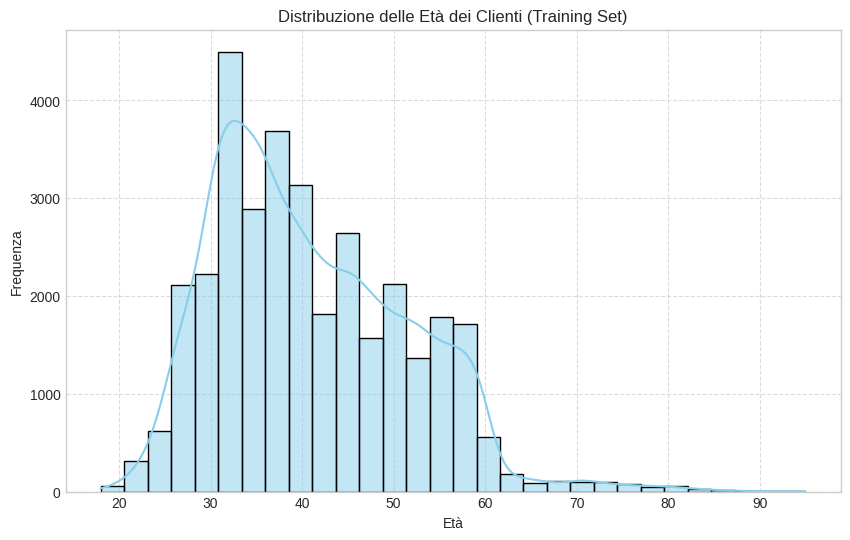

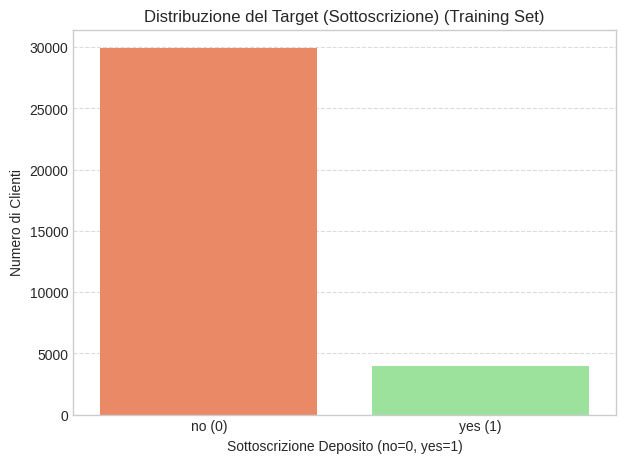

Distribuzione del target nel training set:
0 (no): 88.30%\n1 (yes): 11.70%


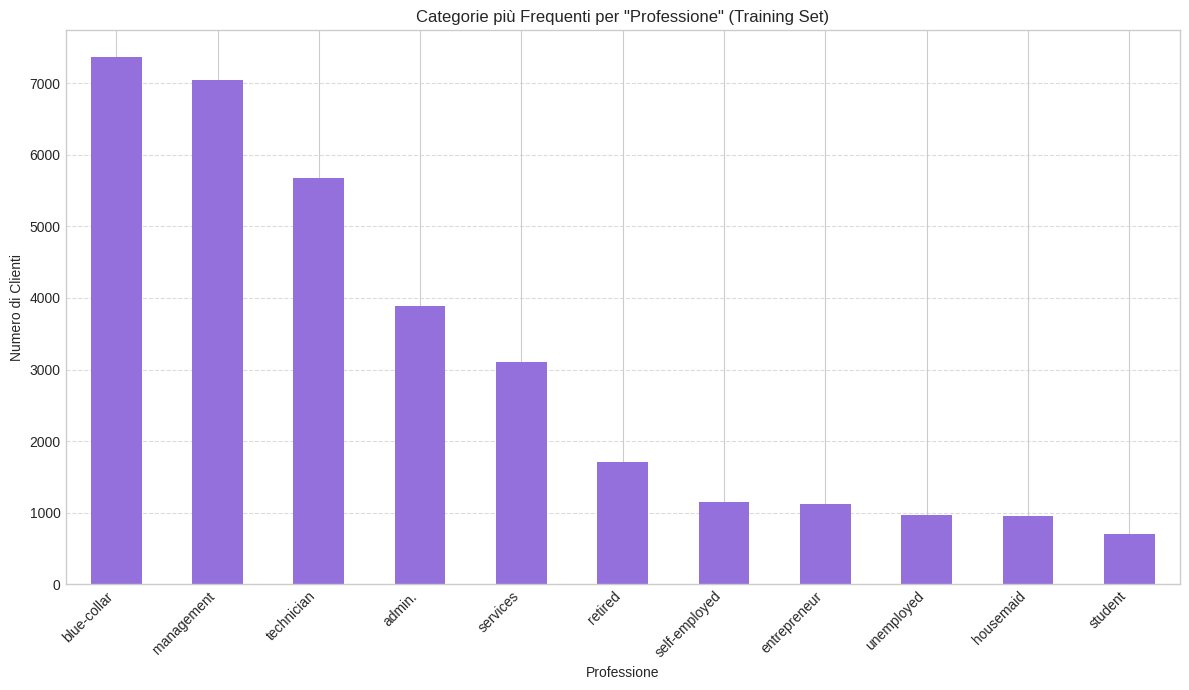

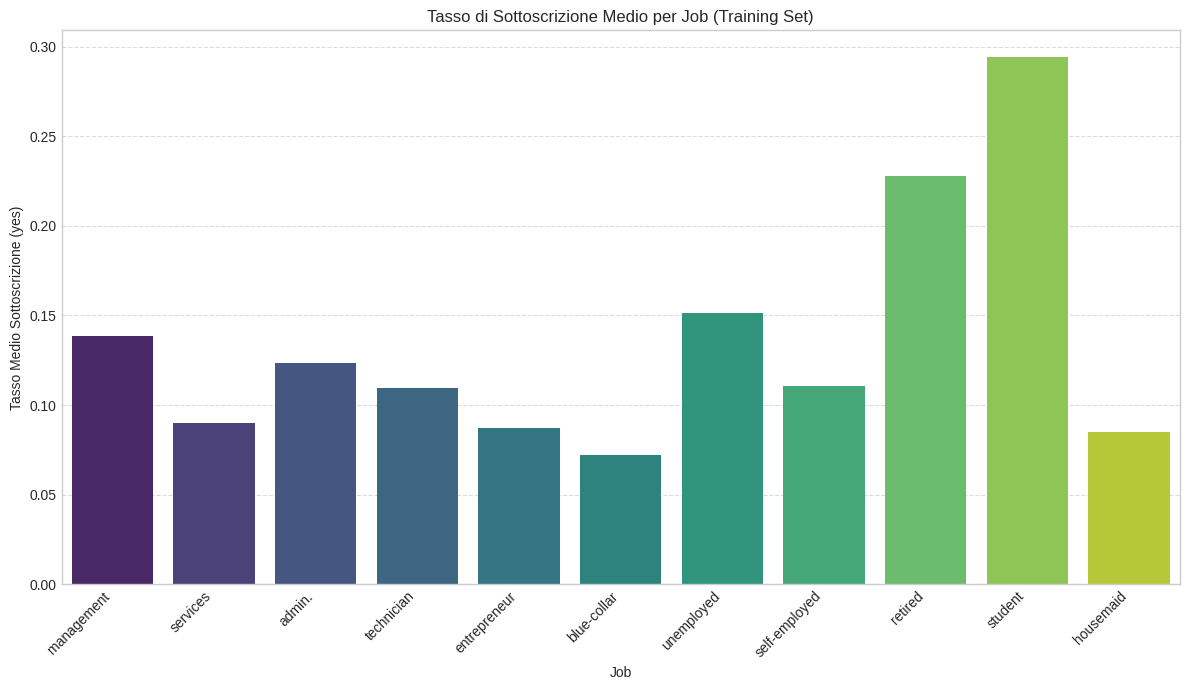

Distribuzione condizionata per job:
                   mean  count
job                           
admin.         0.123650   3890
blue-collar    0.071923   7369
entrepreneur   0.087344   1122
housemaid      0.084906    954
management     0.138759   7041
retired        0.227700   1704
self-employed  0.110919   1154
services       0.090029   3099
student        0.294366    710
technician     0.109447   5674
unemployed     0.151390    971
------------------------------


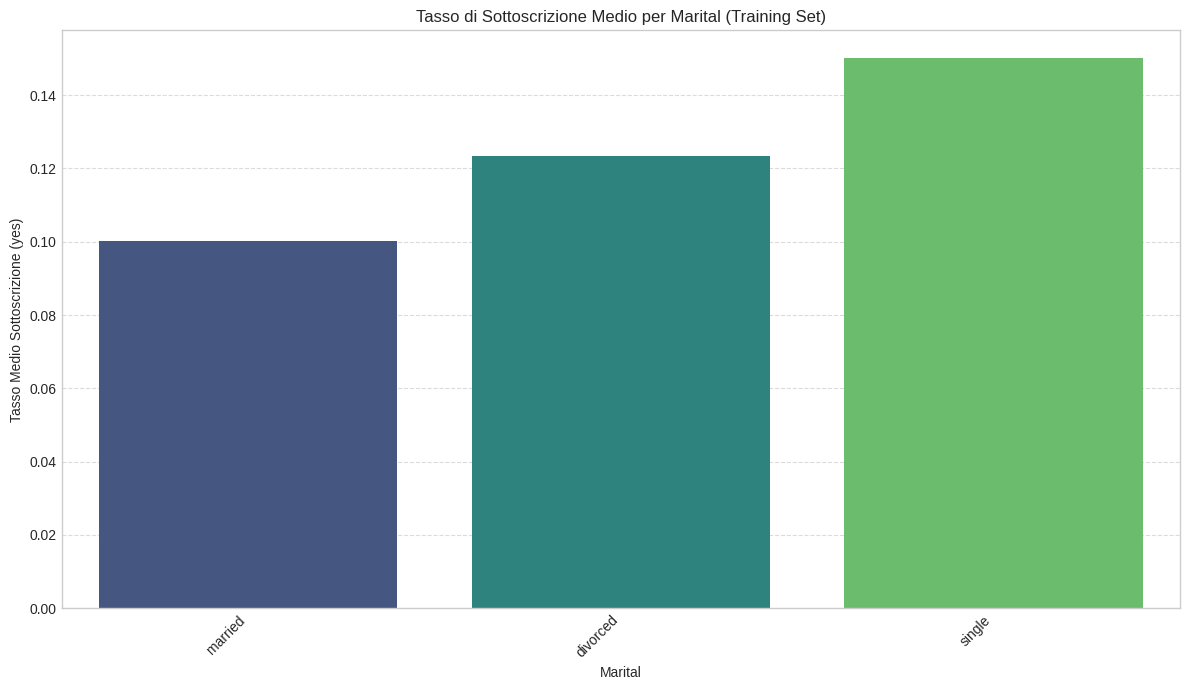

Distribuzione condizionata per marital:
              mean  count
marital                  
divorced  0.123365   3899
married   0.100269  20445
single    0.150146   9564
------------------------------


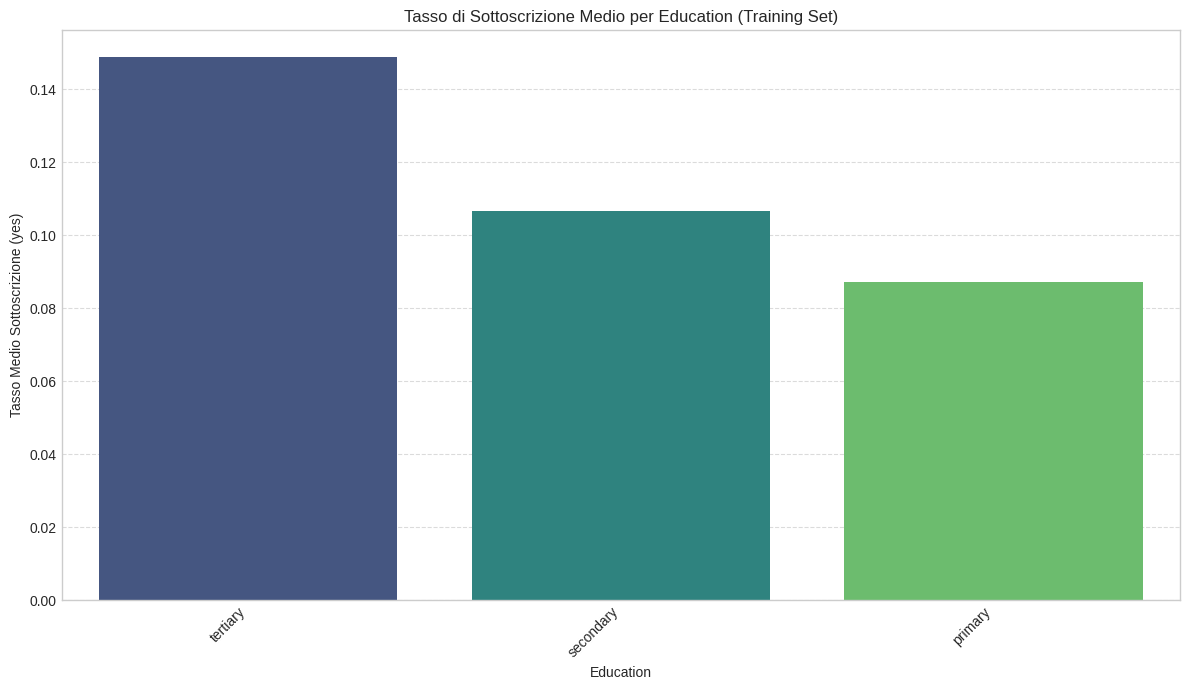

Distribuzione condizionata per education:
               mean  count
education                 
primary    0.087065   5226
secondary  0.106641  17376
tertiary   0.148690   9920
------------------------------


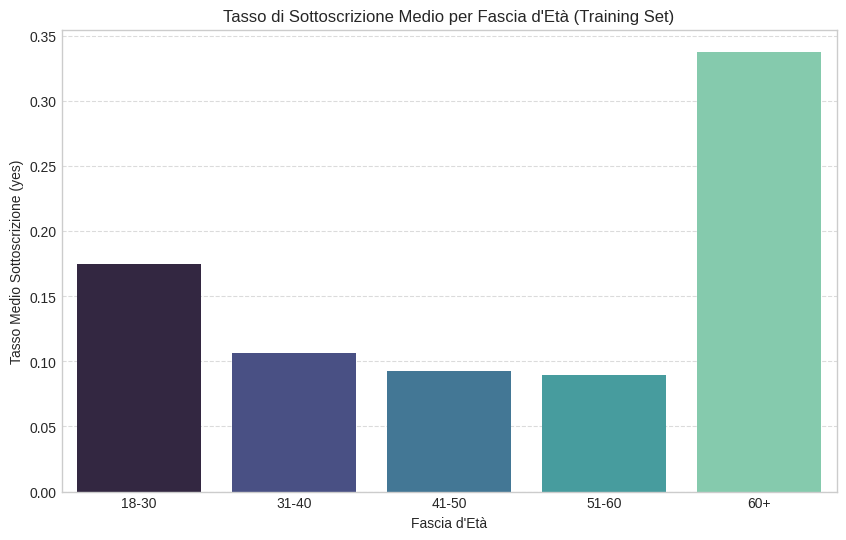

Distribuzione condizionata per Fascia d'Età:
               mean  count
age_group                 
18-30      0.175044   3999
31-40      0.106137  13558
41-50      0.092736   8756
51-60      0.089540   6243
60+        0.338018   1352
------------------------------


In [ ]:
# Utilizziamo il training set originale e uniamo X_train e y_train per l'EDA
df_eda_train = X_train.copy()
df_eda_train['target_subscribed'] = y_train

# Mostriamo statistiche descrittive
print("\nStatistiche descrittive (sul X_train originale):")
print(X_train.describe(include='all').transpose())

# Istogramma della distribuzione dell'età
plt.figure(figsize=(10, 6))
sns.histplot(df_eda_train['age'], kde=True, bins=30, color='skyblue')
plt.title('Distribuzione delle Età dei Clienti (Training Set)')
plt.xlabel('Età')
plt.ylabel('Frequenza')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Grafico a barre per la distribuzione del target (0/1)
plt.figure(figsize=(7, 5))
sns.countplot(x='target_subscribed', data=df_eda_train, palette=['coral', 'lightgreen'])
plt.title('Distribuzione del Target (Sottoscrizione) (Training Set)')
plt.xlabel(f'Sottoscrizione Deposito ({le.classes_[0]}=0, {le.classes_[1]}=1)')
plt.xticks(ticks=[0, 1], labels=[f'{le.classes_[0]} (0)', f'{le.classes_[1]} (1)'])
plt.ylabel('Numero di Clienti')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()
target_counts_train = df_eda_train['target_subscribed'].value_counts(normalize=True)
print(f"Distribuzione del target nel training set:\n0 ({le.classes_[0]}): {target_counts_train.get(0,0):.2%}\\n1 ({le.classes_[1]}): {target_counts_train.get(1,0):.2%}")


# Grafico a barre per la frequenza delle professioni
plt.figure(figsize=(12, 7))
df_eda_train['job'].value_counts().plot(kind='bar', color='mediumpurple')
plt.title('Categorie più Frequenti per "Professione" (Training Set)')
plt.xlabel('Professione')
plt.ylabel('Numero di Clienti')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Analisi del tasso di sottoscrizione per attributi sensibili
sensitive_attributes_for_eda = ['job', 'marital', 'education']
for attr in sensitive_attributes_for_eda:
    if attr in df_eda_train.columns:
        plt.figure(figsize=(12, 7))
        sns.barplot(x=attr, y='target_subscribed', data=df_eda_train, palette='viridis', ci=None) # ci=None per rimuovere barre errore
        plt.title(f'Tasso di Sottoscrizione Medio per {attr.capitalize()} (Training Set)')
        plt.ylabel(f'Tasso Medio Sottoscrizione ({le.classes_[1]})')
        plt.xlabel(attr.capitalize())
        plt.xticks(rotation=45, ha='right')
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()
        print(f"Distribuzione condizionata per {attr}:")
        print(df_eda_train.groupby(attr)['target_subscribed'].agg(['mean', 'count']))
        print("-" * 30)

# Creiamo gruppi di età per l’analisi per fascia
age_bins = [18, 30, 40, 50, 60, 100]
age_labels = ['18-30', '31-40', '41-50', '51-60', '60+']
df_eda_train['age_group'] = pd.cut(df_eda_train['age'], bins=age_bins, labels=age_labels, right=False)

# Grafico del tasso di sottoscrizione per fascia d'età
plt.figure(figsize=(10, 6))
sns.barplot(x='age_group', y='target_subscribed', data=df_eda_train, palette='mako', ci=None)
plt.title('Tasso di Sottoscrizione Medio per Fascia d\'Età (Training Set)')
plt.ylabel(f'Tasso Medio Sottoscrizione ({le.classes_[1]})')
plt.xlabel('Fascia d\'Età')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()
print("Distribuzione condizionata per Fascia d'Età:")
print(df_eda_train.groupby('age_group')['target_subscribed'].agg(['mean', 'count']))
print("-" * 30)

# **CELLA 7**

In questa cella, applichiamo una forma semplice di K-Anonymity al nostro training set (`X_train`) per illustrare il concetto. Scegliamo alcuni QI e applichiamo tecniche di generalizzazione (come il raggruppamento dell'età già visto in EDA). infine verifichiamo se il dataset risultante soddisfa una data soglia *k*.

Quasi-Identificatori scelti: ['age', 'job', 'marital']

Prime righe del DataFrame con QI generalizzati (esempio per 'age'):
      age_generalized         job   marital
24915             50+  management   married
11794           18-49    services  divorced
1279            18-49  management    single
913             18-49      admin.  divorced
5554            18-49      admin.    single

Numero di classi di equivalenza (combinazioni uniche di QI): 72
Distribuzione delle dimensioni delle classi di equivalenza (prime 10):
count
0     3
5     1
6     2
7     1
9     1
16    1
18    3
27    1
28    1
34    1
Name: count, dtype: int64


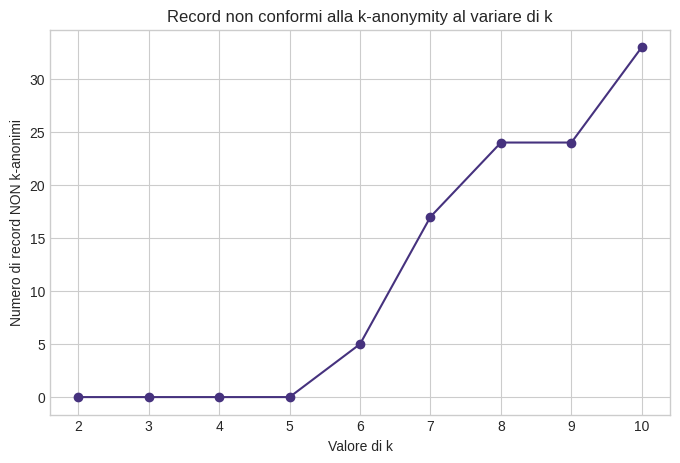

In [ ]:
# Copiamo i dati di training per non modificare l'originale per altre analisi
df_anon = X_train.copy()

# Scegliamo i Quasi-Identificatori (QI)
qi_columns = ['age', 'job', 'marital']
print(f"Quasi-Identificatori scelti: {qi_columns}")

# Generalizzaziamo i QI
age_bins_anon = [18, 50, 100]
age_labels_anon = ['18-49', '50+']


df_anon['age_generalized'] = pd.cut(df_anon['age'], bins=age_bins_anon, labels=age_labels_anon, right=False)


qi_generalized_columns = ['age_generalized', 'job', 'marital']


# Gestione dei valori mancanti nei QI
for col in qi_generalized_columns:
    if df_anon[col].isnull().any():
        if df_anon[col].dtype == 'object':
            df_anon[col] = df_anon[col].astype('category')
        if pd.api.types.is_categorical_dtype(df_anon[col]):
            if 'Unknown' not in df_anon[col].cat.categories:
                df_anon[col] = df_anon[col].cat.add_categories('Unknown')
            df_anon[col].fillna('Unknown', inplace=True)
        else:
            df_anon[col].fillna(df_anon[col].mode()[0], inplace=True)

# Creiamo il dataset con solo i QI
df_qi_anon = df_anon[qi_generalized_columns].copy()

print("\nPrime righe del DataFrame con QI generalizzati (esempio per 'age'):")
print(df_qi_anon.head())

# Classi di equivalenza
equivalence_classes = df_qi_anon.groupby(qi_generalized_columns).size().reset_index(name='count')
print(f"\nNumero di classi di equivalenza (combinazioni uniche di QI): {len(equivalence_classes)}")
print("Distribuzione delle dimensioni delle classi di equivalenza (prime 10):") # Mostra solo le prime 10 per brevità
print(equivalence_classes['count'].value_counts().sort_index().head(10))


# Valutiamo diversi valori di k
k_values = list(range(2, 11))
not_k_anonymous_counts = []

total_records = len(df_anon)

for k in k_values:
    records_not_k = equivalence_classes[equivalence_classes['count'] < k]['count'].sum()
    not_k_anonymous_counts.append(records_not_k)

# Visualizzazione
plt.figure(figsize=(8, 5))
plt.plot(k_values, not_k_anonymous_counts, marker='o')
plt.title("Record non conformi alla k-anonymity al variare di k")
plt.xlabel("Valore di k")
plt.ylabel("Numero di record NON k-anonimi")
plt.grid(True)
plt.show()

In [ ]:
# scegliamo un valore di k
k_value = 5
print(f"Valore di k scelto: {k_value}")

# Verifichiamo quanti record NON soddisfano la k-anonymity
records_not_k_anonymous = equivalence_classes[equivalence_classes['count'] < k_value]['count'].sum()
total_records = len(df_anon) # Usa df_anon per il totale, non df_qi_anon che è solo QI
percent_not_k_anonymous = (records_not_k_anonymous / total_records) * 100

print(f"\nNumero di record che appartengono a classi di equivalenza con meno di {k_value} membri: {records_not_k_anonymous}")
print(f"Percentuale di record che non soddisfano k={k_value} anonymity: {percent_not_k_anonymous:.2f}%")

if records_not_k_anonymous == 0:
    print(f"Il dataset soddisfa la k-anonymity per k={k_value} con i QI scelti e le generalizzazioni applicate.")
else:
    print(f"Il dataset NON soddisfa la k-anonymity per k={k_value}. Sarebbe necessaria ulteriore generalizzazione o soppressione.")

Valore di k scelto: 5

Numero di record che appartengono a classi di equivalenza con meno di 5 membri: 0
Percentuale di record che non soddisfano k=5 anonymity: 0.00%
Il dataset soddisfa la k-anonymity per k=5 con i QI scelti e le generalizzazioni applicate.


# **CELLA 8**
# 4. Riduzione Dimensionale (PCA)


In questa sezione applichiamo la Principal Component Analysis (PCA) per ridurre la dimensionalità del dataset pre-processato a 2 componenti principali, al fine di facilitarne la visualizzazione in uno spazio bidimensionale.

- Utilizziamo PCA per comprimere l'informazione mantenendo la massima varianza possibile.

- Visualizziamo i dati trasformati in un grafico scatter, colorando i punti in base alla classe del target.

- Stampiamo la varianza spiegata da ciascuna componente per valutare quanto dell'informazione originale è mantenuta nella proiezione.

Questo tipo di visualizzazione può aiutare a identificare separazioni tra classi o la presenza di sovrapposizioni, che possono influire sulle performance dei modelli.

Shape dopo PCA: (33908, 2)
Varianza spiegata da ciascuna componente: [0.15632577 0.11395922]
Varianza spiegata totale dalle 2 componenti: 0.27


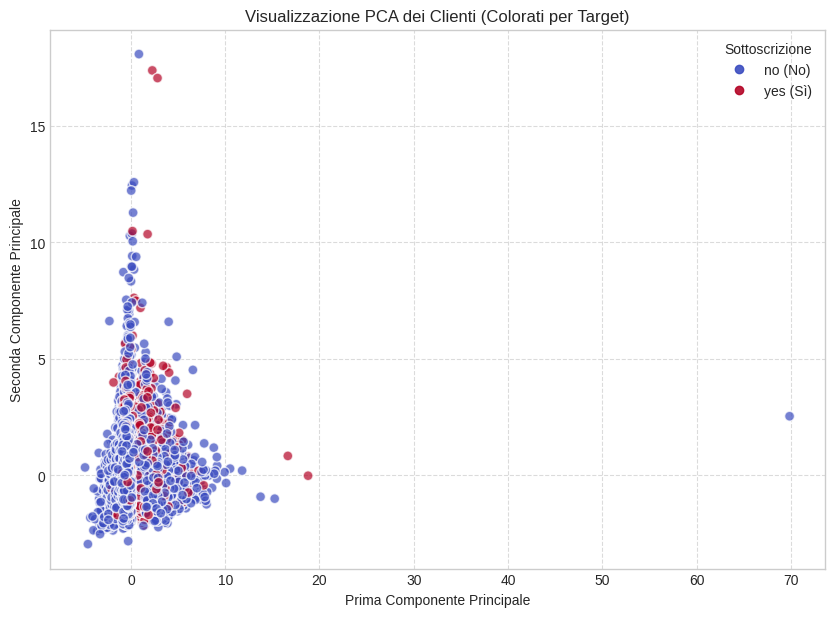

Il plot PCA mostra che i dati sono piuttosto sovrapposti, indicando che una separazione lineare semplice in 2D è difficile.


In [ ]:
pca = PCA(n_components=2, random_state=42)
X_train_pca = pca.fit_transform(X_train_processed_df)

print(f"Shape dopo PCA: {X_train_pca.shape}")
print(f"Varianza spiegata da ciascuna componente: {pca.explained_variance_ratio_}")
print(f"Varianza spiegata totale dalle 2 componenti: {pca.explained_variance_ratio_.sum():.2f}")

plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, cmap='coolwarm', alpha=0.7, edgecolors='w', s=50)
plt.title('Visualizzazione PCA dei Clienti (Colorati per Target)')
plt.xlabel('Prima Componente Principale')
plt.ylabel('Seconda Componente Principale')
handles, _ = scatter.legend_elements(prop="colors", alpha=0.9)
legend_labels = [f"{le.classes_[0]} (No)", f"{le.classes_[1]} (Sì)"]
if len(handles) == 1 and len(np.unique(y_train)) > 1:
     handles = [plt.Line2D([0], [0], marker='o', color='w', label=legend_labels[i],
                          markerfacecolor=scatter.cmap(scatter.norm(i))) for i in np.unique(y_train)]
plt.legend(handles=handles, labels=legend_labels, title="Sottoscrizione")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()
print("Il plot PCA mostra che i dati sono piuttosto sovrapposti, indicando che una separazione lineare semplice in 2D è difficile.")


# **CELLA 9**
# 5. Clustering
 Applichiamo K-Means sui dati ridotti con PCA per esplorare visivamente eventuali raggruppamenti naturali nei dati.

 Questo è un approccio non supervisionato.

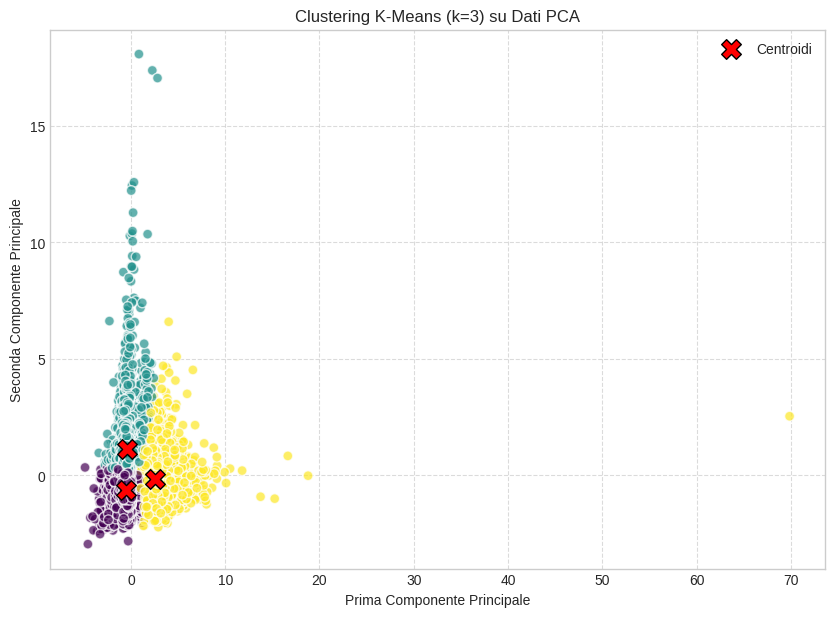

K-Means applicato sui dati PCA. I 3 cluster potrebbero non mappare direttamente il target.


In [ ]:
k_clusters = 3 # numero clusters
kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init='auto')
clusters_pca = kmeans.fit_predict(X_train_pca)

plt.figure(figsize=(10, 7))
scatter_kmeans = plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=clusters_pca, cmap='viridis', alpha=0.7, edgecolors='w', s=50)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], marker='X', s=200, color='red', label='Centroidi', edgecolors='k')
plt.title(f'Clustering K-Means (k={k_clusters}) su Dati PCA')
plt.xlabel('Prima Componente Principale')
plt.ylabel('Seconda Componente Principale')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()
print(f"K-Means applicato sui dati PCA. I {k_clusters} cluster potrebbero non mappare direttamente il target.")

# **CELLA 10**
# 6. Modellazione Predittiva - Funzione di Valutazione e Logistic Regression
 Definiamo una funzione per valutare i modelli e addestriamo una Regressione Logistica come baseline.
 Includiamo class_weight='balanced' per gestire lo sbilanciamento del target.


Addestramento Logistic Regression...

 Valutazione: Logistic Regression 
Accuracy: 0.8481
Precision (per classe 1 - yes): 0.4227
Recall (per classe 1 - yes): 0.8169
F1-Score (per classe 1 - yes): 0.5571

Classification Report:
              precision    recall  f1-score   support

          no       0.97      0.85      0.91      9981
         yes       0.42      0.82      0.56      1322

    accuracy                           0.85     11303
   macro avg       0.70      0.83      0.73     11303
weighted avg       0.91      0.85      0.87     11303



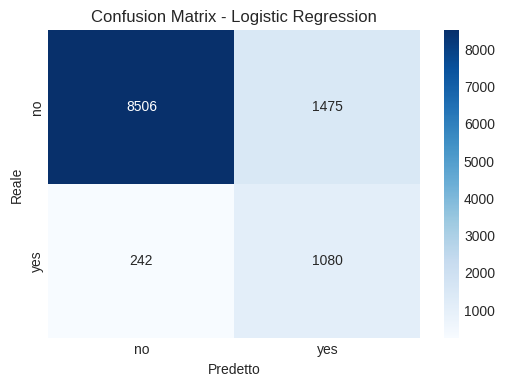


Metriche di Equità per Logistic Regression rispetto a 'marital':
  Selection Rate (marital=married - Privilegiato): 0.2155
  Selection Rate (marital!= married - Non Privilegiato): 0.2280
  Demographic Parity Difference: 0.0125
  Disparate Impact (Ratio): 1.0580
  True Positive Rate (marital=married - Privilegiato): 0.7906
  True Positive Rate (marital!= married - Non Privilegiato): 0.8214
  Equal Opportunity Difference: 0.0308


In [ ]:
# Funzione per valutare i modelli
def evaluate_model(name, model, X_test_data, y_test_data, class_labels, X_test_original_features=None, sensitive_attr_name=None, privileged_group_val=None):
    preds = model.predict(X_test_data)
    proba_preds = model.predict_proba(X_test_data)[:, 1]

    accuracy = accuracy_score(y_test_data, preds)
    precision = precision_score(y_test_data, preds, zero_division=0)
    recall = recall_score(y_test_data, preds, zero_division=0)
    f1 = f1_score(y_test_data, preds, zero_division=0)

    print(f"\n Valutazione: {name} ")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision (per classe 1 - {class_labels[1]}): {precision:.4f}")
    print(f"Recall (per classe 1 - {class_labels[1]}): {recall:.4f}")
    print(f"F1-Score (per classe 1 - {class_labels[1]}): {f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test_data, preds, target_names=class_labels, zero_division=0))

    cm = confusion_matrix(y_test_data, preds)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
    plt.xlabel('Predetto')
    plt.ylabel('Reale')
    plt.title(f'Confusion Matrix - {name}')
    plt.show()

    results_dict = {'model_name': name, 'accuracy': accuracy, 'precision': precision, 'recall': recall, 'f1': f1}

    # Calcoliamo metriche di equità se gli attributi sono forniti
    if X_test_original_features is not None and sensitive_attr_name and privileged_group_val is not None:
        print(f"\nMetriche di Equità per {name} rispetto a '{sensitive_attr_name}':")
        df_fairness = pd.DataFrame({'y_true': y_test_data, 'y_pred': preds})
        # Allineiamo X_test_original_features con y_test_data per assicurarci che gli indici corrispondano
        df_fairness[sensitive_attr_name] = X_test_original_features.loc[X_test_data.index, sensitive_attr_name]

        # Tasso di selezione per il gruppo privilegiato
        sel_rate_privileged = df_fairness[df_fairness[sensitive_attr_name] == privileged_group_val]['y_pred'].mean()

        # Tasso di selezione per il gruppo non privilegiato (tutti gli altri)
        sel_rate_unprivileged = df_fairness[df_fairness[sensitive_attr_name] != privileged_group_val]['y_pred'].mean()

        print(f"  Selection Rate ({sensitive_attr_name}={privileged_group_val} - Privilegiato): {sel_rate_privileged:.4f}")
        print(f"  Selection Rate ({sensitive_attr_name}!= {privileged_group_val} - Non Privilegiato): {sel_rate_unprivileged:.4f}")

        demographic_parity_diff = sel_rate_unprivileged - sel_rate_privileged
        print(f"  Demographic Parity Difference: {demographic_parity_diff:.4f}")
        results_dict['demographic_parity_diff'] = demographic_parity_diff

        if sel_rate_privileged > 0:
            disparate_impact = sel_rate_unprivileged / sel_rate_privileged
            print(f"  Disparate Impact (Ratio): {disparate_impact:.4f}")
            results_dict['disparate_impact'] = disparate_impact
        else:
            print("  Disparate Impact (Ratio): N/A (tasso selezione gruppo privilegiato è 0)")
            results_dict['disparate_impact'] = np.nan

        # TPR per il gruppo privilegiato
        true_pos_privileged = df_fairness[(df_fairness[sensitive_attr_name] == privileged_group_val) & (df_fairness['y_true'] == 1)]
        tpr_privileged = true_pos_privileged['y_pred'].mean() if len(true_pos_privileged) > 0 else np.nan

        # TPR per il gruppo non privilegiato
        true_pos_unprivileged = df_fairness[(df_fairness[sensitive_attr_name] != privileged_group_val) & (df_fairness['y_true'] == 1)]
        tpr_unprivileged = true_pos_unprivileged['y_pred'].mean() if len(true_pos_unprivileged) > 0 else np.nan

        print(f"  True Positive Rate ({sensitive_attr_name}={privileged_group_val} - Privilegiato): {tpr_privileged:.4f}")
        print(f"  True Positive Rate ({sensitive_attr_name}!= {privileged_group_val} - Non Privilegiato): {tpr_unprivileged:.4f}")

        equal_opportunity_diff = tpr_unprivileged - tpr_privileged
        print(f"  Equal Opportunity Difference: {equal_opportunity_diff:.4f}")
        results_dict['equal_opportunity_diff'] = equal_opportunity_diff

    return results_dict

# Logistic Regression
print("\nAddestramento Logistic Regression...")
log_reg = LogisticRegression(random_state=42, max_iter=1000, solver='liblinear', class_weight='balanced')
log_reg.fit(X_train_processed_df, y_train)
log_reg_metrics = evaluate_model("Logistic Regression", log_reg, X_test_processed_df, y_test, le.classes_,
                                 X_test_original_features=X_test, sensitive_attr_name='marital', privileged_group_val='married')



# **CELLA 11**
# 6. Modellazione Predittiva, Gradient Boosting e Confronto Modelli
 Addestriamo un Gradient Boosting Classifier e confrontiamo le sue performance con la Regressione Logistica.


 Valutazione: Gradient Boosting 
Accuracy: 0.9042
Precision (per classe 1 - yes): 0.6435
Recall (per classe 1 - yes): 0.4054
F1-Score (per classe 1 - yes): 0.4974

Classification Report:
              precision    recall  f1-score   support

          no       0.92      0.97      0.95      9981
         yes       0.64      0.41      0.50      1322

    accuracy                           0.90     11303
   macro avg       0.78      0.69      0.72     11303
weighted avg       0.89      0.90      0.89     11303



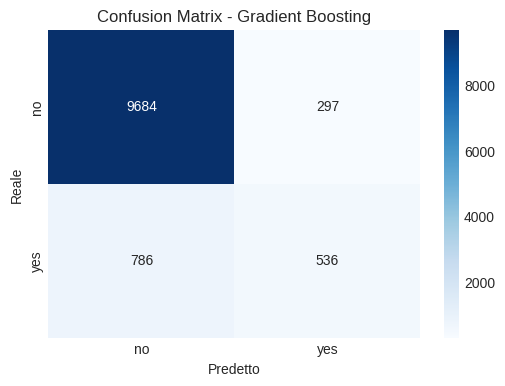


Metriche di Equità per Gradient Boosting rispetto a 'marital':
  Selection Rate (marital=married - Privilegiato): 0.0676
  Selection Rate (marital!= married - Non Privilegiato): 0.0748
  Demographic Parity Difference: 0.0072
  Disparate Impact (Ratio): 1.1062
  True Positive Rate (marital=married - Privilegiato): 0.3874
  True Positive Rate (marital!= married - Non Privilegiato): 0.4085
  Equal Opportunity Difference: 0.0211
                     accuracy        f1  demographic_parity_diff  \
model_name                                                         
Logistic Regression  0.848093  0.557132                 0.012504   
Gradient Boosting    0.904185  0.497448                 0.007185   

                     equal_opportunity_diff  disparate_impact  
model_name                                                     
Logistic Regression                0.030821          1.058030  
Gradient Boosting                  0.021054          1.106248  


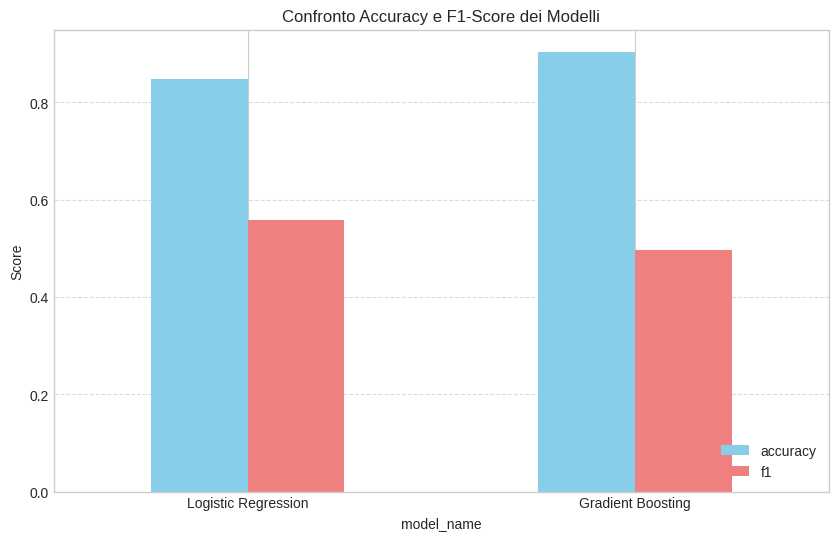

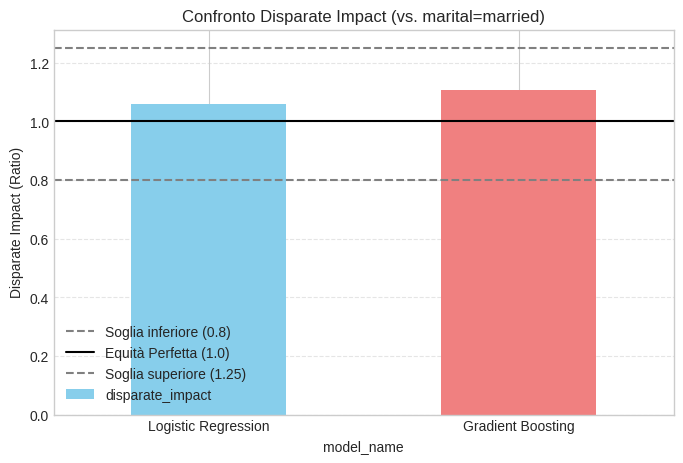

In [ ]:
gb_clf = GradientBoostingClassifier(n_estimators=100, random_state=42, learning_rate=0.1, max_depth=3)
gb_clf.fit(X_train_processed_df, y_train)

# Valutazione del Gradient Boosting includendo metriche di equità
gb_clf_metrics = evaluate_model("Gradient Boosting", gb_clf, X_test_processed_df, y_test, le.classes_,
                                X_test_original_features=X_test, sensitive_attr_name='marital', privileged_group_val='married')


# Confrontiamo le metriche di performance e fairness tra i modelli
performance_data = [log_reg_metrics, gb_clf_metrics]
performance_df = pd.DataFrame(performance_data).set_index('model_name')
print(performance_df[['accuracy', 'f1', 'demographic_parity_diff', 'equal_opportunity_diff', 'disparate_impact']]) # Mostra più metriche

performance_df[['accuracy', 'f1']].plot(kind='bar', figsize=(10,6), color=['skyblue', 'lightcoral'])
plt.title('Confronto Accuracy e F1-Score dei Modelli')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(loc='lower right')
plt.show()

# Grafico per Disparate Impact
if 'disparate_impact' in performance_df.columns:
    plt.figure(figsize=(8, 5))
    performance_df['disparate_impact'].plot(kind='bar', color=['skyblue', 'lightcoral'])
    plt.axhline(y=0.8, color='grey', linestyle='--', label='Soglia inferiore (0.8)')
    plt.axhline(y=1.0, color='black', linestyle='-', label='Equità Perfetta (1.0)')
    plt.axhline(y=1.25, color='grey', linestyle='--', label='Soglia superiore (1.25)')
    plt.title(f'Confronto Disparate Impact (vs. marital=married)')
    plt.ylabel('Disparate Impact (Ratio)')
    plt.xticks(rotation=0)
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.show()

# **CELLA 12**
# 7. Interpretabilità - Feature Importance & Partial Dependence Plots (PDP)
 Estraiamo le feature importance dal Gradient Boosting e generiamo PDP per capire l'effetto
 marginale delle feature più importanti sulle predizioni.
 Colleghiamo l'interpretabilità alla potenziale presenza di bias.

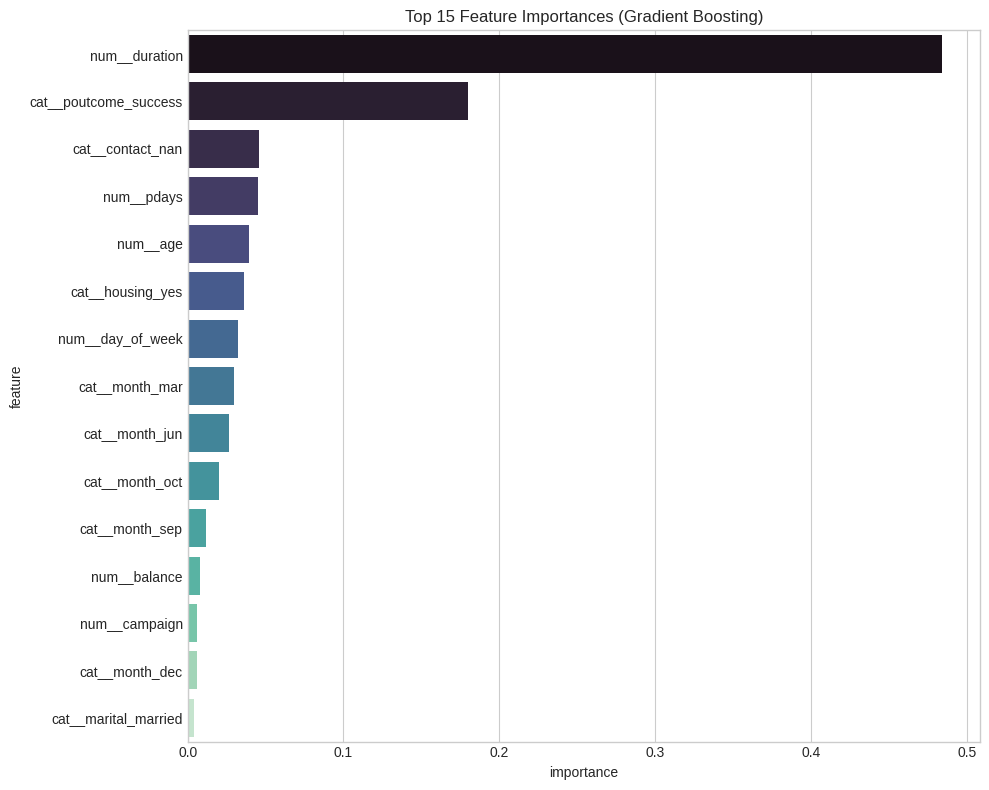

Generazione Partial Dependence Plots per: ['num__age', 'num__duration'] sul modello Gradient Boosting...


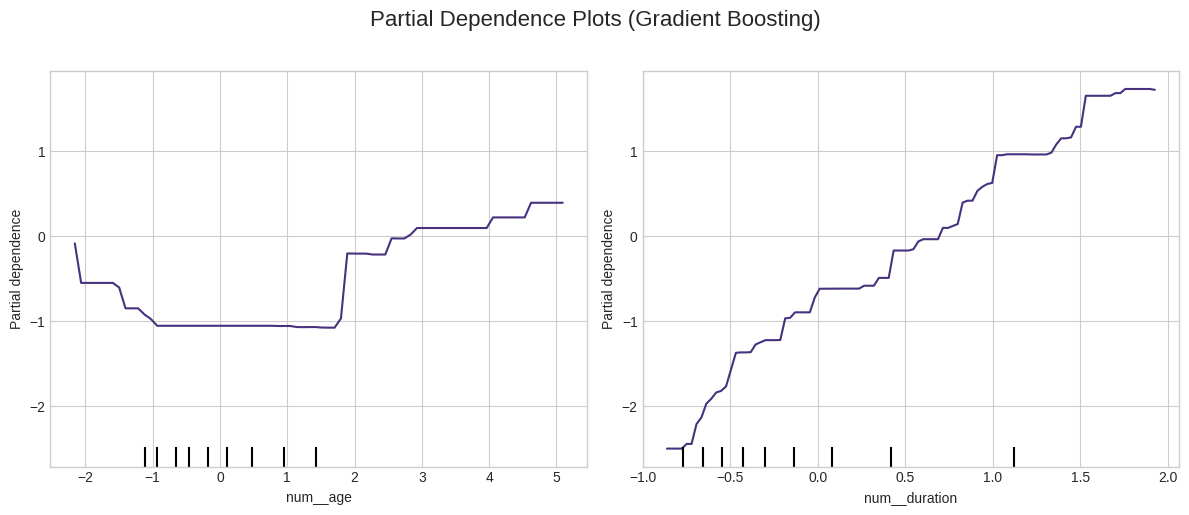

In [ ]:
# Calcoliamo l'importanza delle feature dal modello Gradient Boosting

importances = gb_clf.feature_importances_
feature_importances_df = pd.DataFrame({'feature': feature_names_processed, 'importance': importances})
feature_importances_df = feature_importances_df.sort_values('importance', ascending=False).head(15)


# Visualizziamo le 15 feature più importanti
plt.figure(figsize=(10, 8))
sns.barplot(x='importance', y='feature', data=feature_importances_df, palette='mako')
plt.title('Top 15 Feature Importances (Gradient Boosting)')
plt.tight_layout()
plt.show()

# Selezioniamo le feature per il PDP dai nomi delle feature processate
processed_numeric_features = [f for f in feature_names_processed if f.startswith('num__')]
pdp_target_plot_features = []

if not processed_numeric_features:
    print("Nessuna feature numerica processata trovata per PDP.")
elif len(processed_numeric_features) >= 2:
    # Proviamo con 'num__age' e 'num__duration' se esistono, altrimenti le prime due numeriche
    selected_for_pdp = []
    if 'num__age' in processed_numeric_features: selected_for_pdp.append('num__age')
    if 'num__duration' in processed_numeric_features: selected_for_pdp.append('num__duration')

    # Se non ne abbiamo trovate due specifiche, prendiamo le prime disponibili
    if len(selected_for_pdp) < 2 and len(processed_numeric_features) > 0:
        remaining_needed = 2 - len(selected_for_pdp)
        for feat in processed_numeric_features:
            if feat not in selected_for_pdp and remaining_needed > 0:
                selected_for_pdp.append(feat)
                remaining_needed -=1
    pdp_target_plot_features = selected_for_pdp

elif processed_numeric_features:
    pdp_target_plot_features = processed_numeric_features[:1]
else:
    print("Nessuna feature numerica adatta trovata per PDP.")


# Generazione dei PDP per le feature selezionate
if pdp_target_plot_features:
    print(f"Generazione Partial Dependence Plots per: {pdp_target_plot_features} sul modello Gradient Boosting...")
    n_features_to_plot = len(pdp_target_plot_features)
    ncols_pdp = min(n_features_to_plot, 2)
    nrows_pdp = (n_features_to_plot + ncols_pdp - 1) // ncols_pdp

    fig, ax_array = plt.subplots(
        figsize=(6 * ncols_pdp, 5 * nrows_pdp),
        ncols=ncols_pdp,
        nrows=nrows_pdp,
        squeeze=False
    )
    ax_flat = ax_array.ravel()

    # Visualizziamo i PDP
    PartialDependenceDisplay.from_estimator(
        estimator=gb_clf,
        X=X_train_processed_df,
        features=pdp_target_plot_features,
        ax=ax_flat
    )
    # Rimuoviamo eventuali assi vuoti
    for i in range(n_features_to_plot, len(ax_flat)):
        fig.delaxes(ax_flat[i])

    plt.suptitle("Partial Dependence Plots (Gradient Boosting)", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("Skipping PDP: no suitable features found or selected.")


# **CELLA 13**
## 7. Interpretabilità - LIME
 Applichiamo LIME per spiegare una singola predizione del modello Gradient Boosting.


Istanza originale da spiegare (riga 0 del test set):
       age         job marital  education default  balance housing loan  \
22684   33  technician  single  secondary      no        9      no  yes   

        contact  day_of_week month  duration  campaign  pdays  previous  \
22684  cellular           25   aug       145         8     -1         0   

      poutcome  
22684      NaN  
Target reale: no (0)
Predizione del modello GB: no
Probabilità predette dal GB (no | yes): 0.9726 | 0.0274

Spiegazione LIME per la classe predetta (no):
Feature: cat__month_mar <= 0.00, Peso: 0.2255
Feature: cat__poutcome_success <= 0.00, Peso: 0.2178
Feature: cat__month_oct <= 0.00, Peso: 0.1646
Feature: cat__month_dec <= 0.00, Peso: 0.1299
Feature: -0.60 < num__duration <= -0.30, Peso: 0.1284
Feature: cat__month_jun <= 0.00, Peso: 0.0983
Feature: cat__month_sep <= 0.00, Peso: 0.0939
Feature: cat__contact_nan <= 0.00, Peso: -0.0785
Feature: cat__month_jan <= 0.00, Peso: 0.0708
Feature: cat__housing_ye

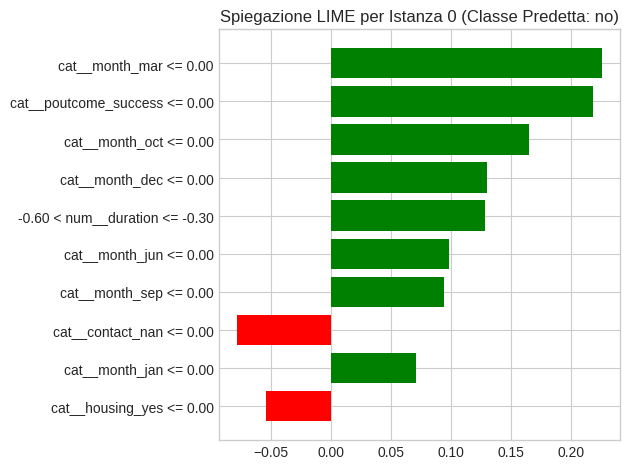

In [ ]:
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_processed_np,
    feature_names=list(X_train_processed_df.columns),
    class_names=list(le.classes_),
    mode='classification',
    random_state=42
)

idx_to_explain = 0 # Spieghiamo la prima istanza del test set
instance_to_explain_np = X_test_processed_np[idx_to_explain]
original_instance_info = X_test.iloc[[idx_to_explain]]

print(f"\nIstanza originale da spiegare (riga {idx_to_explain} del test set):")
print(original_instance_info)

actual_label = y_test[idx_to_explain]
predicted_label_gb = gb_clf.predict(instance_to_explain_np.reshape(1, -1))[0]
predicted_proba_gb = gb_clf.predict_proba(instance_to_explain_np.reshape(1, -1))[0]

print(f"Target reale: {le.classes_[actual_label]} ({actual_label})")
print(f"Predizione del modello GB: {le.classes_[predicted_label_gb]}")
print(f"Probabilità predette dal GB ({le.classes_[0]} | {le.classes_[1]}): {predicted_proba_gb[0]:.4f} | {predicted_proba_gb[1]:.4f}")

num_lime_features = 10
lime_explanation = lime_explainer.explain_instance(
    data_row=instance_to_explain_np,
    predict_fn=gb_clf.predict_proba,
    num_features=num_lime_features,
    top_labels=1
)

print(f"\nSpiegazione LIME per la classe predetta ({le.classes_[predicted_label_gb]}):")
for feature, weight in lime_explanation.as_list(label=predicted_label_gb):
    print(f"Feature: {feature}, Peso: {weight:.4f}")

fig = lime_explanation.as_pyplot_figure(label=predicted_label_gb)
plt.title(f"Spiegazione LIME per Istanza {idx_to_explain} (Classe Predetta: {le.classes_[predicted_label_gb]})", fontsize=12)
plt.tight_layout()
plt.show()



# **CELLA 14**
## Mitigazione del Bias con Reweighting
In questa cella applichiamo una tecnica di fairness mitigation, il Reweighting.

Calcoliamo i nuovi pesi per ogni combinazione di marital e target (yes/no), in modo da bilanciare il dataset rispetto alle frequenze osservate.

Applichiamo questi pesi durante il riaddestramento della Logistic Regression.

Alla fine, confrontiamo il nuovo modello reweighted con il modello originale valutando sia le performance predittive che le metriche di fairness.




Addestramento Logistic Regression con Reweighing

 Valutazione: Logistic Regression (Reweighed vs marital) 
Accuracy: 0.9006
Precision (per classe 1 - yes): 0.6415
Recall (per classe 1 - yes): 0.3411
F1-Score (per classe 1 - yes): 0.4454

Classification Report:
              precision    recall  f1-score   support

          no       0.92      0.97      0.95      9981
         yes       0.64      0.34      0.45      1322

    accuracy                           0.90     11303
   macro avg       0.78      0.66      0.70     11303
weighted avg       0.89      0.90      0.89     11303



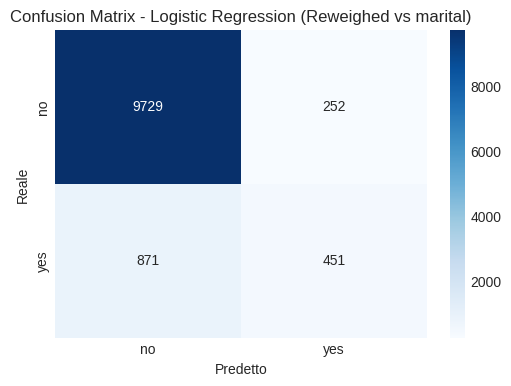


Metriche di Equità per Logistic Regression (Reweighed vs marital) rispetto a 'marital':
  Selection Rate (marital=married - Privilegiato): 0.0516
  Selection Rate (marital!= married - Non Privilegiato): 0.0641
  Demographic Parity Difference: 0.0126
  Disparate Impact (Ratio): 1.2435
  True Positive Rate (marital=married - Privilegiato): 0.2984
  True Positive Rate (marital!= married - Non Privilegiato): 0.3484
  Equal Opportunity Difference: 0.0499

Confronto metriche Logistic Regression Originale vs Reweighed (vs marital):
                                            accuracy        f1  \
model_name                                                       
Logistic Regression                         0.848093  0.557132   
Logistic Regression (Reweighed vs marital)  0.900646  0.445432   

                                            demographic_parity_diff  \
model_name                                                            
Logistic Regression                                        0.

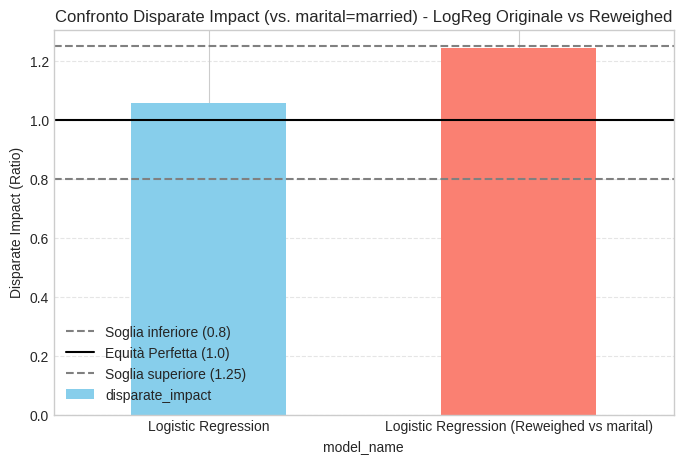

In [ ]:
if 'marital' in X_train.columns:
    df_train_reweigh = X_train.copy()
    df_train_reweigh['target_subscribed'] = y_train

    # Probabilità marginali osservate sul training set
    P_s_marital = df_train_reweigh['marital'].value_counts(normalize=True)
    P_y_subscribed = df_train_reweigh['target_subscribed'].value_counts(normalize=True)

    # Probabilità congiunte P(s,y)
    P_sy_marital_subscribed = pd.crosstab(df_train_reweigh['marital'], df_train_reweigh['target_subscribed'], normalize=True)

    weights_map_reweigh = {}
    for marital_status in P_s_marital.index:
        for subscribed_status in P_y_subscribed.index:
            if P_sy_marital_subscribed.loc[marital_status, subscribed_status] > 0:
                numerator = P_s_marital[marital_status] * P_y_subscribed[subscribed_status]
                denominator = P_sy_marital_subscribed.loc[marital_status, subscribed_status]
                weights_map_reweigh[(marital_status, subscribed_status)] = numerator / denominator
            else:
                weights_map_reweigh[(marital_status, subscribed_status)] = 1.0 # Peso neutro se la combinazione non esiste

    # Applichiamo i pesi al training set (X_train)
    sample_weights_train = df_train_reweigh.apply(
        lambda row: weights_map_reweigh.get((row['marital'], row['target_subscribed']), 1.0), axis=1
    ).values

    # Riaddestriamo Logistic Regression con i pesi
    print("\nAddestramento Logistic Regression con Reweighing")
    log_reg_reweighed = LogisticRegression(random_state=42, max_iter=1000, solver='liblinear') # Non usare class_weight qui
    log_reg_reweighed.fit(X_train_processed_df, y_train, sample_weight=sample_weights_train)

    log_reg_reweighed_metrics = evaluate_model(
        "Logistic Regression (Reweighed vs marital)",
        log_reg_reweighed,
        X_test_processed_df,
        y_test,
        le.classes_,
        X_test_original_features=X_test,
        sensitive_attr_name='marital',
        privileged_group_val='married'
    )

    # Confrontiamo con il modello LogReg originale
    print("\nConfronto metriche Logistic Regression Originale vs Reweighed (vs marital):")
    comparison_df_reweigh = pd.DataFrame([log_reg_metrics, log_reg_reweighed_metrics]).set_index('model_name')
    print(comparison_df_reweigh[['accuracy', 'f1', 'demographic_parity_diff', 'equal_opportunity_diff', 'disparate_impact']])

    if 'disparate_impact' in comparison_df_reweigh.columns:
        plt.figure(figsize=(8, 5))
        comparison_df_reweigh['disparate_impact'].plot(kind='bar', color=['skyblue', 'salmon'])
        plt.axhline(y=0.8, color='grey', linestyle='--', label='Soglia inferiore (0.8)')
        plt.axhline(y=1.0, color='black', linestyle='-', label='Equità Perfetta (1.0)')
        plt.axhline(y=1.25, color='grey', linestyle='--', label='Soglia superiore (1.25)')
        plt.title(f'Confronto Disparate Impact (vs. marital=married) - LogReg Originale vs Reweighed')
        plt.ylabel('Disparate Impact (Ratio)')
        plt.xticks(rotation=0)
        plt.legend()
        plt.grid(axis='y', linestyle='--', alpha=0.5)
        plt.show()

else:
    print("Attributo 'marital' non trovato in X_train per l'esempio di Reweighing.")


# **CELLA 15**

# 11. Considerazioni sulla Privacy dei Dati

L'analisi dei dati in un contesto bancario, come quello del dataset "Bank Marketing", solleva importanti questioni relative alla privacy e alla protezione delle informazioni personali dei clienti.

Sebbene questo progetto si sia concentrato principalmente sulla modellazione predittiva, sull'equità e sull'interpretabilità, è fondamentale considerare come questi aspetti si intrecciano con la privacy.

# Dati Sensibili e Normative

Il dataset contiene informazioni demografiche (come età, lavoro, stato civile, istruzione) e finanziarie (bilancio), che sono considerate personali e sensibili. Di conseguenza, in un contesto reale, la raccolta, l'archiviazione e l'utilizzo di tali dati sarebbero soggetti a vincoli normativi stringenti, come il GDPR.

# Collegamento tra Equità, Bias e Privacy

L'analisi del bias e la ricerca dell'equità, che abbiamo affrontato, sono strettamente correlate alla privacy. Un modello che discrimina sulla base di attributi sensibili (es. età o stato civile) non solo è ingiusto, ma può anche portare a una violazione delle aspettative di riservatezza delle persone coinvolte, poiché decisioni avverse potrebbero essere prese sulla base di caratteristiche che l'individuo considera private o protette. Evitare che il modello amplifichi bias esistenti contribuisce quindi a un uso più etico e responsabile dei dati personali.

# Interpretabilità e Rischi di Re-identificazione
- Strumenti come LIME e Partial Dependence Plots aiutano a rendere i modelli più trasparenti. Tuttavia, quando si basano su combinazioni uniche o molto rare di feature, possono evidenziare pattern troppo specifici, aumentando il rischio, anche involontario, di re-identificazione o fuga di informazioni sensibili.
- Nel corso dell'Analisi Esplorativa dei Dati (EDA), abbiamo raggruppato la feature 'age' in fasce. Questa tecnica è simile al processo di generalizzazione usato nella K-anonymity, una strategia di anonimizzazione che rende ogni record indistinguibile da almeno k-1 altri record rispetto a un insieme di “quasi-identificatori”.
Sebbene nel nostro progetto il raggruppamento dell'età sia stato fatto per scopi esplorativi e per l'analisi del bias, in un'applicazione reale, tecniche di generalizzazione o soppressione potrebbero essere applicate più formalmente per anonimizzare il dataset prima dell'analisi, riducendo il rischio di re-identificazione individuale e proteggendo la privacy.

# Considerazioni finali

In uno scenario reale, un’analisi di questo tipo richiederebbe un rigoroso processo di Data Governance, come la valutazione d’impatto sulla privacy (DPIA) e l'adozione di misure tecniche specifiche (es. anonimizzazione, pseudonimizzazione o anche Differential Privacy, seppur non implementata qui). Inoltre, la trasparenza verso gli utenti rispetto a come vengono trattati i loro dati è fondamentale.

In conclusione, questo progetto dimostra come la privacy sia un aspetto da considerare fin dall’inizio nel ciclo di vita dei dati. Anche quando non vengono applicate tecniche avanzate di protezione, è essenziale mantenere consapevolezza dei rischi potenziali e delle implicazioni etiche delle nostre scelte di analisi e modellazione.

# 12. Conclusioni

 Ripercorriamo i passaggi eseguiti:
 - Caricamento, comprensione iniziale dei dati e riflessione sui potenziali bias e sull'autenticità.
 - Pre-processing accurato dei dati, includendo la gestione di variabili numeriche e categoriche.
 - Analisi Esplorativa dei Dati (EDA), con un focus specifico sull'identificazione preliminare
   di possibili disparità tra gruppi di clienti.
 - Tecniche di Privacy: abbiamo svolto una dimostrazione pratica di K-Anonymity, illustrando il concetto di anonimizzazione tramite generalizzazione e la sua verifica  
 - Utilizzo di PCA per la riduzione dimensionale e la visualizzazione, e K-Means per una segmentazione
   non supervisionata della clientela.
 - Sviluppo e confronto di modelli predittivi: una Regressione Logistica e un Gradient Boosting Classifier.
 - Valutazione rigorosa dei modelli non solo in termini di performance aggregate (accuracy, F1-score)
   ma anche attraverso metriche di equità (es. Demographic Parity, Equal Opportunity Difference)
   per quantificare il bias nelle predizioni.
 - Applicazione di tecniche di interpretabilità:
   - Feature Importance (Gradient Boosting) per una visione globale.
   - Partial Dependence Plots (PDP) per analizzare l'effetto marginale di feature specifiche.
   - LIME per ottenere spiegazioni locali per singole predizioni.